# Imbalanced classification: 4 algorithms, SMOTE vs undersampling, and why accuracy lies

In many real problems the class we care about is **rare**: fraud, disease, machine failure, customers about to leave. This notebook walks through:

1. **The accuracy trap.** Why accuracy is misleading on imbalanced data
2. **Four algorithms:** Logistic Regression, KNN, Decision Tree, Random Forest
3. **Overfitting or underfitting?** Comparing train and test scores
4. **Balancing with SMOTE** (create synthetic minority examples)
5. **Balancing with undersampling** (throw away majority examples)
6. **Comparing results** with precision, recall and F1
7. **ROC curves and AUC**, plus a look at precision-recall curves and choosing a threshold

> **Setup:** `uv add pandas numpy matplotlib scikit-learn imbalanced-learn jupyter`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay,
)

from imblearn.datasets import fetch_datasets
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline   # like sklearn's Pipeline, but it also accepts samplers

RANDOM_STATE = 42
pd.set_option("display.precision", 3)

## 1. The data

The **mammography** dataset: 11,183 mammogram image regions, each described by 6 numeric features. The task is to find the regions showing **calcifications**, a possible sign of cancer.

- `1` = calcification: the rare class we care about (**positive**)
- `0` = normal tissue (**negative**)

In [2]:
data = fetch_datasets(filter_data=("mammography",))["mammography"]

X = pd.DataFrame(data.data, columns=[f"feature_{i}" for i in range(data.data.shape[1])])
y = pd.Series((data.target == 1).astype(int), name="calcification")

print("Shape:", X.shape)
X.head()

Shape: (11183, 6)


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5
0,0.230,5.073,-0.276,0.832,-0.378,0.480
1,0.155,-0.169,0.671,-0.860,-0.378,-0.946
2,-0.784,-0.444,5.675,-0.860,-0.378,-0.946
3,0.546,0.131,-0.456,-0.860,-0.378,-0.946
4,-0.103,-0.395,-0.141,0.980,-0.378,1.014


calcification
0    10923
1      260
Name: count, dtype: int64

Positive class: 2.3% of the data, about 1 in 42


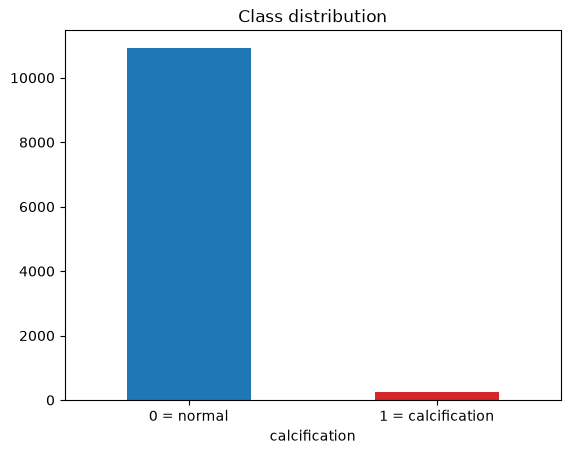

In [3]:
counts = y.value_counts()
print(counts)
print(f"\nPositive class: {y.mean():.1%} of the data, about 1 in {round(counts[0] / counts[1])}")

counts.plot(kind="bar", title="Class distribution", color=["tab:blue", "tab:red"])
plt.xticks([0, 1], ["0 = normal", "1 = calcification"], rotation=0)
plt.show()

## 2. The accuracy trap

What if a "model" ignores the data and **always predicts the majority class** ("normal")?

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)
# stratify=y keeps the same 2.3% positives in both train and test

always_normal = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred = always_normal.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, pred):.1%}")
print(f"Recall:   {recall_score(y_test, pred):.1%}   <- calcifications found")

Accuracy: 97.7%
Recall:   0.0%   <- calcifications found


**About 98% accuracy, and it finds zero calcifications.** A useless model looks excellent on accuracy, because accuracy is dominated by the majority class.

So for imbalanced problems we look at:

| Metric | Question it answers |
|---|---|
| **Precision** | Of the cases we flagged, how many were really positive? (false alarms) |
| **Recall** | Of all the real positives, how many did we catch? (misses) |
| **F1** | A single score balancing precision and recall |
| **ROC-AUC** | How well does the model *rank* positives above negatives, across every threshold? |

## 3. Four algorithms, no balancing

A small helper trains a model and scores it on **both** train and test data. Comparing the two is how we spot overfitting.

Each model sits in a **pipeline** with a `StandardScaler`, because KNN and Logistic Regression need scaled features.

In [5]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}


def scores(model, X, y):
    pred = model.predict(X)
    proba = model.predict_proba(X)[:, 1]
    return {
        "accuracy": accuracy_score(y, pred),
        "precision": precision_score(y, pred, zero_division=0),
        "recall": recall_score(y, pred),
        "f1": f1_score(y, pred),
        "roc_auc": roc_auc_score(y, proba),
    }


def run(strategy, sampler=None):
    """Train all 4 models with an optional sampler; return the fitted models and a results table."""
    fitted, rows = {}, []
    for name, model in MODELS.items():
        steps = [("scale", StandardScaler())]
        if sampler is not None:
            steps.append(("balance", sampler))
        steps.append(("model", clone(model)))   # a fresh, untrained copy for every strategy
        pipe = Pipeline(steps).fit(X_train, y_train)
        fitted[name] = pipe
        for split, (Xs, ys) in {"train": (X_train, y_train), "test": (X_test, y_test)}.items():
            rows.append({"strategy": strategy, "model": name, "split": split, **scores(pipe, Xs, ys)})
    return fitted, pd.DataFrame(rows)


baseline_models, baseline = run("No balancing")
baseline.pivot(index="model", columns="split", values=["accuracy", "precision", "recall", "f1"])

accuracy        precision        recall            f1  \
split                   test  train      test  train   test  train   test   
model                                                                       
Decision Tree          0.978  1.000     0.521  1.000  0.585  0.979  0.551   
KNN                    0.985  0.989     0.811  0.908  0.462  0.605  0.588   
Logistic Regression    0.982  0.984     0.750  0.804  0.369  0.400  0.495   
Random Forest          0.986  1.000     0.846  1.000  0.508  0.979  0.635   

                            
split                train  
model                       
Decision Tree        0.990  
KNN                  0.726  
Logistic Regression  0.534  
Random Forest        0.990

**Notice:** accuracy is about 98% for every model, yet **recall** (calcifications actually caught) is much lower. Accuracy alone would hide that.

## 4. Overfitting or underfitting?

Compare **train** and **test** F1:

| Pattern | Diagnosis | What it means |
|---|---|---|
| Train **high**, test much **lower** | **Overfitting** | The model memorised the training data |
| Train **low**, test **low** | **Underfitting** | The model is too simple to learn the pattern |
| Train ≈ test, both reasonable | **Good fit** | It generalises |

In [6]:
def diagnose(results, metric="f1", gap=0.15, low=0.6):
    table = results.pivot(index="model", columns="split", values=metric)
    table["gap"] = table["train"] - table["test"]

    def verdict(row):
        if row["gap"] > gap:
            return "Overfitting"
        if row["train"] < low:
            return "Underfitting"
        return "Good fit"

    table["diagnosis"] = table.apply(verdict, axis=1)
    return table


diagnose(baseline)

split,test,train,gap,diagnosis
model,,,,
Decision Tree,0.551,0.990,0.439,Overfitting
KNN,0.588,0.726,0.138,Good fit
Logistic Regression,0.495,0.534,0.039,Underfitting
Random Forest,0.635,0.990,0.355,Overfitting


**Typical results:**
- The **Decision Tree** and **Random Forest** score (almost) perfectly on training data but much lower on test data, which is classic **overfitting**: they memorised the rare positives.
- **Logistic Regression** is the opposite: low on both, so it is **underfitting**. A straight-line boundary is too simple here, and the imbalance pushes it towards always saying "normal".

### Seeing it: tree depth

A tree's `max_depth` controls its complexity. Using 5-fold cross-validation **on the training data only**:

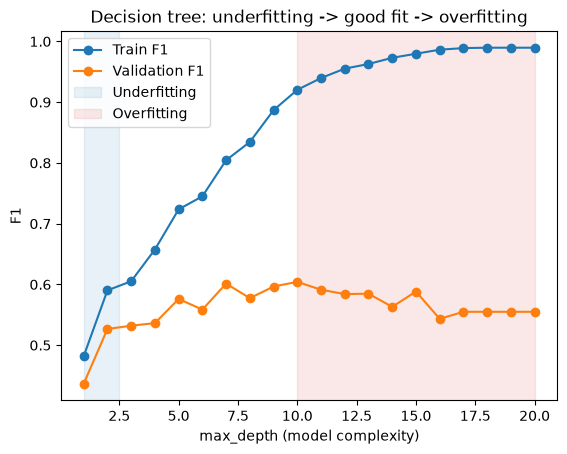

In [7]:
depths = range(1, 21)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_f1, val_f1 = [], []
for d in depths:
    result = cross_validate(
        DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE),
        X_train, y_train, cv=cv, scoring="f1", return_train_score=True,
    )
    train_f1.append(result["train_score"].mean())
    val_f1.append(result["test_score"].mean())

plt.plot(depths, train_f1, marker="o", label="Train F1")
plt.plot(depths, val_f1, marker="o", label="Validation F1")
plt.axvspan(1, 2.5, alpha=0.1, color="tab:blue", label="Underfitting")
plt.axvspan(10, 20, alpha=0.1, color="tab:red", label="Overfitting")
plt.xlabel("max_depth (model complexity)")
plt.ylabel("F1")
plt.title("Decision tree: underfitting -> good fit -> overfitting")
plt.legend()
plt.show()

- **Shallow trees** (left): train and validation are both low, so the tree is **underfitting**.
- **Deep trees** (right): train F1 climbs towards 1.0 while validation stalls or drops, so it is **overfitting**.
- The **sweet spot** is where validation F1 peaks.

## 5. Balancing with SMOTE

**SMOTE** (Synthetic Minority Over-sampling Technique) creates **new, synthetic** positive examples. It picks a positive, picks one of its nearest positive neighbours, and creates a new point somewhere on the line between them.

```
   ● real positive                 ● real positive
          \                       /
           ○ ← synthetic point created between them
```

> ⚠️ **Only ever resample the training data.** The test set must stay as it is in the real world (2.3% positive). Putting SMOTE **inside the pipeline** guarantees this: it runs during `fit` and is skipped during `predict`.

In [8]:
X_smote, y_smote = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)

print("Training data before SMOTE:", dict(y_train.value_counts()))
print("Training data after SMOTE: ", dict(pd.Series(y_smote).value_counts()))

Training data before SMOTE: {0: np.int64(8192), 1: np.int64(195)}
Training data after SMOTE:  {0: np.int64(8192), 1: np.int64(8192)}


In [9]:
smote_models, smote = run("SMOTE", SMOTE(random_state=RANDOM_STATE))
smote.pivot(index="model", columns="split", values=["precision", "recall", "f1"])

precision        recall            f1       
split                    test  train   test  train   test  train
model                                                           
Decision Tree           0.407  1.000  0.708  0.979  0.517  0.990
KNN                     0.331  0.406  0.831  0.974  0.474  0.573
Logistic Regression     0.187  0.162  0.908  0.836  0.310  0.271
Random Forest           0.562  1.000  0.769  0.979  0.649  0.990

## 6. Balancing with random undersampling

The opposite idea: **remove** majority examples at random until both classes are the same size.

| | SMOTE (oversampling) | Random undersampling |
|---|---|---|
| How | Create synthetic positives | Delete negatives |
| Training size | Grows | **Shrinks a lot** |
| Risk | Synthetic points can add noise | Throws away useful information |
| Good when | You have little data | You have lots of data, or training is slow |

In [10]:
X_under, y_under = RandomUnderSampler(random_state=RANDOM_STATE).fit_resample(X_train, y_train)

print("Training data before undersampling:", dict(y_train.value_counts()))
print("Training data after undersampling: ", dict(pd.Series(y_under).value_counts()))

Training data before undersampling: {0: np.int64(8192), 1: np.int64(195)}
Training data after undersampling:  {0: np.int64(195), 1: np.int64(195)}


In [11]:
under_models, under = run("Undersampling", RandomUnderSampler(random_state=RANDOM_STATE))
under.pivot(index="model", columns="split", values=["precision", "recall", "f1"])

precision        recall            f1       
split                    test  train   test  train   test  train
model                                                           
Decision Tree           0.139  0.145  0.892  0.979  0.241  0.253
KNN                     0.171  0.156  0.908  0.903  0.287  0.266
Logistic Regression     0.172  0.149  0.877  0.841  0.287  0.253
Random Forest           0.207  0.210  0.938  0.979  0.340  0.346

## 7. Comparing everything: precision, recall, F1

All 12 combinations (4 models × 3 strategies), on the **test** set:

In [12]:
all_results = pd.concat([baseline, smote, under])
test_results = all_results[all_results["split"] == "test"]

comparison = test_results.pivot(index="model", columns="strategy", values=["precision", "recall", "f1"])
comparison = comparison.reindex(columns=["No balancing", "SMOTE", "Undersampling"], level=1)
comparison

precision                            recall         \
strategy            No balancing  SMOTE Undersampling No balancing  SMOTE   
model                                                                       
Decision Tree              0.521  0.407         0.139        0.585  0.708   
KNN                        0.811  0.331         0.171        0.462  0.831   
Logistic Regression        0.750  0.187         0.172        0.369  0.908   
Random Forest              0.846  0.562         0.207        0.508  0.769   

                                            f1                       
strategy            Undersampling No balancing  SMOTE Undersampling  
model                                                                
Decision Tree               0.892        0.551  0.517         0.241  
KNN                         0.908        0.588  0.474         0.287  
Logistic Regression         0.877        0.495  0.310         0.287  
Random Forest               0.938        0.635  0.649         0.340

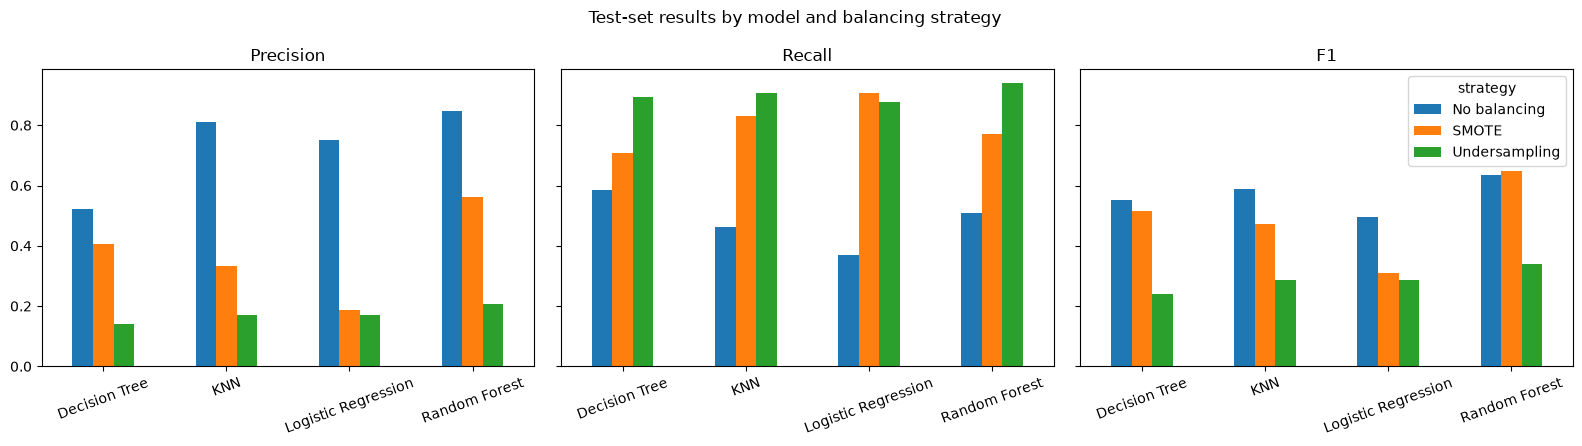

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
for ax, metric in zip(axes, ["precision", "recall", "f1"]):
    test_results.pivot(index="model", columns="strategy", values=metric)[
        ["No balancing", "SMOTE", "Undersampling"]
    ].plot(kind="bar", ax=ax, rot=20, legend=(metric == "f1"))
    ax.set_title(metric.capitalize())
    ax.set_xlabel("")
plt.suptitle("Test-set results by model and balancing strategy")
plt.tight_layout()
plt.show()

**What to look for:**
- Balancing **raises recall**: the models catch many more calcifications.
- It usually **lowers precision**: more false alarms.
- **Undersampling** pushes recall highest but precision collapses: it threw away about 98% of the normal examples, so the model sees "normal" far less often.
- **F1** shows which combination gets the best *balance* of the two.

There's always a **trade-off**. Which side matters more is a **business decision**:
- Missing a cancer (a false negative) is far worse than an extra check (a false positive), so you'd **favour recall**.
- For a spam filter, deleting a real email is worse than letting spam through, so you'd **favour precision**.

### The same story in confusion matrices (Random Forest)

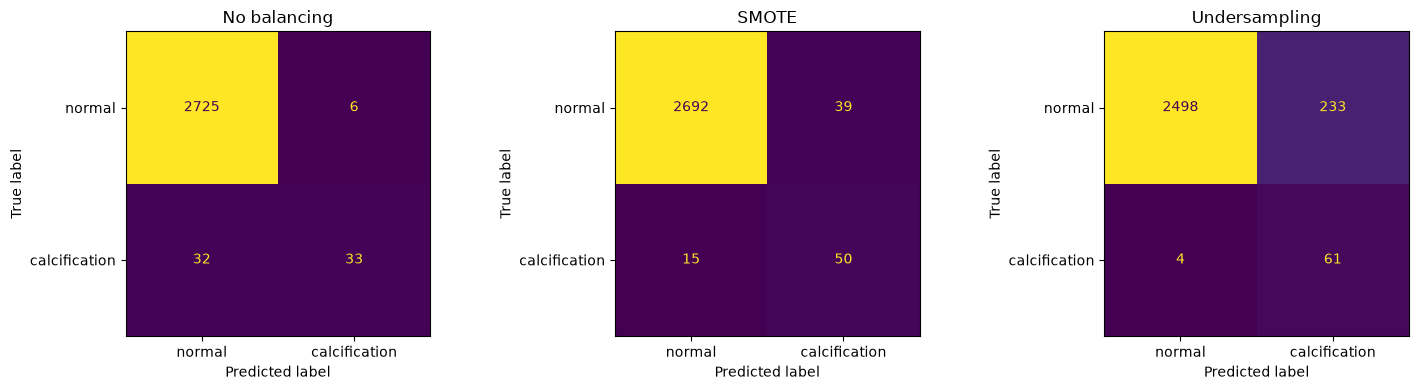

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (strategy, models) in zip(axes, {
    "No balancing": baseline_models, "SMOTE": smote_models, "Undersampling": under_models,
}.items()):
    ConfusionMatrixDisplay.from_estimator(
        models["Random Forest"], X_test, y_test, ax=ax, colorbar=False,
        display_labels=["normal", "calcification"],
    )
    ax.set_title(strategy)
plt.tight_layout()
plt.show()

Read the **bottom row** (real calcifications): the left cell counts **misses** (false negatives), the right cell counts **catches** (true positives). Balancing moves cases from "missed" to "caught", at the cost of more false alarms in the top-right cell.

### Accuracy vs recall, side by side

In [15]:
test_results.pivot_table(index=["strategy", "model"], values=["accuracy", "recall", "f1"])[
    ["accuracy", "recall", "f1"]
]

accuracy  recall     f1
strategy      model                                       
No balancing  Decision Tree           0.978   0.585  0.551
              KNN                     0.985   0.462  0.588
              Logistic Regression     0.982   0.369  0.495
              Random Forest           0.986   0.508  0.635
SMOTE         Decision Tree           0.969   0.708  0.517
              KNN                     0.957   0.831  0.474
              Logistic Regression     0.906   0.908  0.310
              Random Forest           0.981   0.769  0.649
Undersampling Decision Tree           0.869   0.892  0.241
              KNN                     0.895   0.908  0.287
              Logistic Regression     0.899   0.877  0.287
              Random Forest           0.915   0.938  0.340

After balancing, accuracy **goes down** even though recall goes **way up**. If you picked models by accuracy, you'd choose the ones that miss the most calcifications. **On imbalanced data, accuracy doesn't tell you what you need to know.**

## 8. ROC curve and AUC

Every model outputs a **probability**. To get a yes/no answer we pick a **threshold** (0.5 by default). Precision, recall and F1 all depend on that one threshold.

The **ROC curve** shows performance at **every** threshold:
- **y-axis: True Positive Rate** = recall = positives caught
- **x-axis: False Positive Rate** = negatives wrongly flagged

**AUC** (Area Under the Curve) sums it up in one number:

| AUC | Meaning |
|---|---|
| 1.0 | Perfect: every positive is ranked above every negative |
| 0.9+ | Excellent |
| 0.5 | No better than a coin flip (the diagonal line) |

Because it doesn't depend on a threshold or on the class ratio, AUC is a much fairer score than accuracy for imbalanced data.

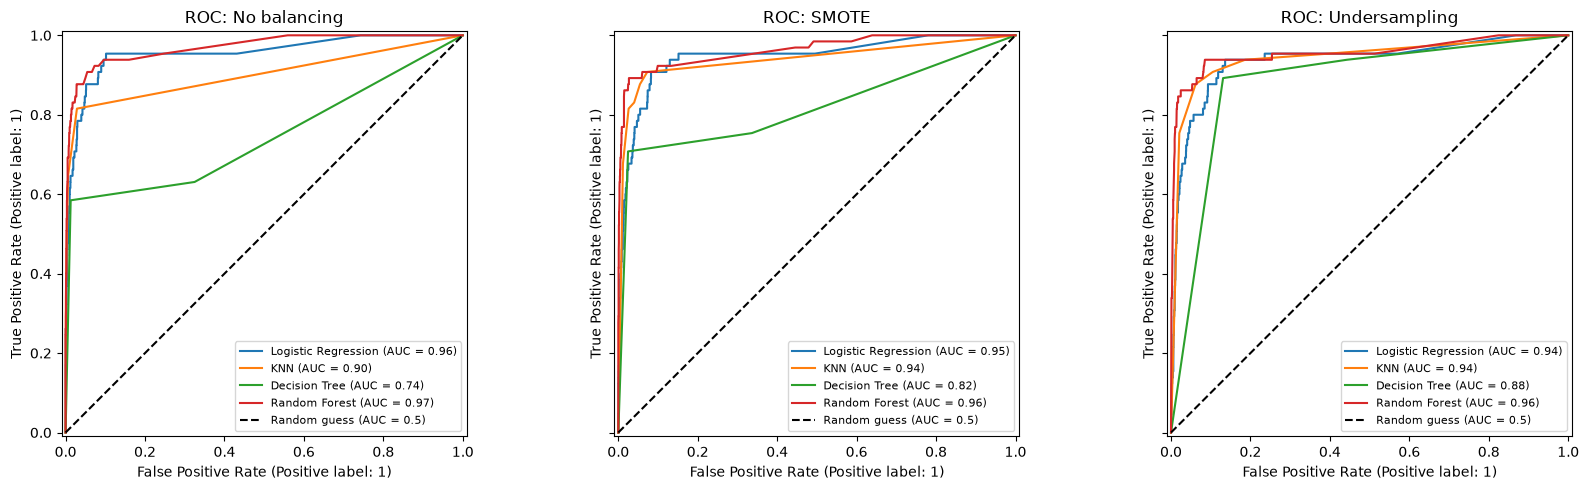

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
for ax, (strategy, models) in zip(axes, {
    "No balancing": baseline_models, "SMOTE": smote_models, "Undersampling": under_models,
}.items()):
    for name, model in models.items():
        RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], "k--", label="Random guess (AUC = 0.5)")
    ax.set_title(f"ROC: {strategy}")
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

In [17]:
auc_table = test_results.pivot(index="model", columns="strategy", values="roc_auc")[
    ["No balancing", "SMOTE", "Undersampling"]
]
auc_table

strategy,No balancing,SMOTE,Undersampling
model,,,
Decision Tree,0.744,0.818,0.884
KNN,0.901,0.939,0.943
Logistic Regression,0.956,0.946,0.937
Random Forest,0.970,0.964,0.955


**Key insight:** for the models that output good probabilities (**Logistic Regression, Random Forest**), balancing changes precision and recall a lot but **AUC hardly at all**. Balancing mostly **moves the threshold**; it doesn't make the model much better at telling the classes apart, which is what AUC measures.

The **unpruned Decision Tree** is the exception. Its leaves are pure, so it only outputs probabilities of 0 or 1, and its "ROC curve" is really a single point joined to the corners, which gives it a poor AUC. Balancing shifts that point, so its AUC changes more. Limiting `max_depth` gives it real probabilities.

So a good workflow is:
1. Use **AUC** to choose the best model.
2. Then **choose the threshold** that gives the precision/recall trade-off the business needs.

### Choosing a threshold

Take the Random Forest trained **without** balancing and simply lower its threshold:

In [18]:
proba = baseline_models["Random Forest"].predict_proba(X_test)[:, 1]

rows = []
for threshold in [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]:
    pred = (proba >= threshold).astype(int)
    rows.append({
        "threshold": threshold,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "flagged": int(pred.sum()),
    })
pd.DataFrame(rows)

,threshold,precision,recall,f1,flagged
0,0.50,0.825,0.508,0.629,40
1,0.40,0.796,0.600,0.684,49
2,0.30,0.726,0.692,0.709,62
3,0.20,0.641,0.769,0.699,78
4,0.10,0.440,0.846,0.579,125
5,0.05,0.299,0.892,0.448,194


Lowering the threshold **raises recall and lowers precision**, much like resampling does, with no change to the training data at all.

Look at the F1 column: simply moving the threshold to around **0.3** gives a **better F1 than any of the resampling strategies** in section 7. Resampling isn't always needed; choosing the right threshold on a good model is often just as effective, and simpler.

### Bonus: the precision-recall curve

With **heavy** imbalance (like 2.3%), ROC can look optimistic, because there are so many negatives that the false positive rate stays small. The **precision-recall curve** and its summary, **average precision (AP)**, focus only on the positive class and are often more informative.

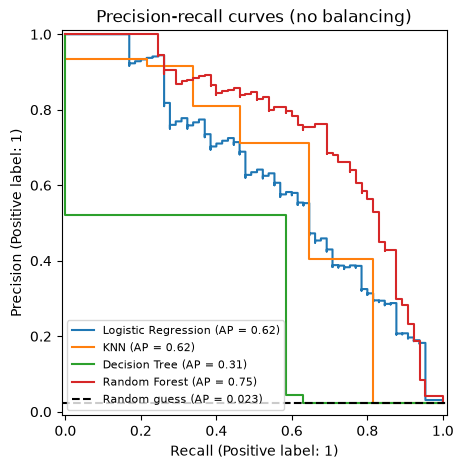

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, model in baseline_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.axhline(y_test.mean(), color="k", linestyle="--", label=f"Random guess (AP = {y_test.mean():.3f})")
ax.set_title("Precision-recall curves (no balancing)")
ax.legend(fontsize=8)
plt.show()

## 9. Summary

| Lesson | Takeaway |
|---|---|
| **Accuracy** | Misleading on imbalanced data: always predicting "normal" scores about 98% |
| **Precision vs recall** | False alarms vs misses. The business decides which matters more |
| **F1** | Balances the two; a good single number for comparing models at a fixed threshold |
| **Overfitting** | Train ≫ test (deep trees, unpruned forests). Fix: limit depth, use more data, regularise |
| **Underfitting** | Train and test both low (too-simple models). Fix: a more flexible model or better features |
| **SMOTE** | Synthetic positives; keeps all the data; resample **only** the training set (inside the pipeline) |
| **Undersampling** | Fewer negatives; fast; highest recall but loses information and precision |
| **ROC-AUC** | Threshold-independent ranking quality: use it to compare models |
| **Threshold** | Tune it to hit the precision/recall trade-off the business needs |
| **PR curve / AP** | Even more informative than ROC when positives are very rare |

## Try it yourself

1. Give the Decision Tree `max_depth=5`. Does the overfitting gap shrink? What happens to test F1?
2. Try `class_weight="balanced"` in Logistic Regression or Random Forest, a third way to handle imbalance with no resampling at all.
3. For the best model, find the threshold that gives at least **80% recall**. What precision do you get?
4. Run this notebook on your own Week 1 dataset, if it's a classification problem.